# Final Work

- Dataset: `outputs/router_level_dataset.csv`
- Flow: 5 single models -> 1 best single model; 5 hybrid models -> 1 best hybrid model
- Final artifacts: leaderboard, confusion matrices, C export


## Run Order

- Run from top to bottom
- Skip install cells if imports already work
- Review single-model leaderboard, hybrid-model leaderboard, and final C-export cells


## Step 1: Install `pandas` If Needed


In [1]:
# Run the commented line only if Step 2 gives an import error in your own environment.
# %pip install pandas
print("Optional install cell skipped because pandas is already available in this environment.")


Optional install cell skipped because pandas is already available in this environment.


## Step 2: Import Core Libraries


In [2]:
from io import StringIO
from pathlib import Path

import pandas as pd
from IPython.display import display

print("Libraries imported successfully.")


Libraries imported successfully.


## Step 3: Display Setup


In [3]:
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 80)

print("Display options are ready.")


Display options are ready.


## Step 4: Dataset Path


In [4]:
dataset_path = Path("outputs") / "router_level_dataset.csv"
print("Dataset path:")
print(dataset_path.resolve())


Dataset path:
D:\New folder\combine\apps\Organized_by_App\outputs\router_level_dataset.csv


## Step 5: File Check


In [5]:
if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset not found: {dataset_path}")

print("Dataset file found.")


Dataset file found.


## Step 6: Load Dataset


In [6]:
df = pd.read_csv(dataset_path)
print("CSV loaded successfully into df.")


CSV loaded successfully into df.


## Step 7: Target Column


In [7]:
target_col = "Category"
y = df[target_col]

print(f"Target column name: {target_col}")
print("First 10 target values:")
display(y.head(10).to_frame(name=target_col))


Target column name: Category
First 10 target values:


,Category
0,Adult
1,Adult
2,Adult
3,Adult
4,Adult
5,Adult
6,Adult
7,Adult
8,Adult
9,Adult


## Step 8: Dataset Snapshot


In [8]:
quick_snapshot = pd.DataFrame(
    [
        {"item": "Rows", "value": f"{df.shape[0]:,}"},
        {"item": "Columns", "value": f"{df.shape[1]:,}"},
        {"item": "Unique apps", "value": f"{df['app_name'].nunique():,}"},
        {"item": "Unique categories", "value": f"{df[target_col].nunique():,}"},
        {"item": "Source split labels in CSV", "value": f"{df['split'].nunique():,}"},
    ]
)

display(quick_snapshot)


,item,value
0,Rows,"62,898"
1,Columns,117
2,Unique apps,200
3,Unique categories,4
4,Source split labels in CSV,2


## Step 9: First Rows


In [9]:
display(df.head())


,record_id,Category,app_name,split,transport_protocol,ip_version,protocol_family,flow_pattern_guess,traffic_type,traffic_type_confidence,traffic_type_is_guessed,app_behavior_hint,src_port,dst_port,is_tcp,is_udp,is_https,is_dns,is_http,duration_seconds,forward_duration_seconds,backward_duration_seconds,long_flow,orig_packets,resp_packets,total_packets,orig_bytes,resp_bytes,total_bytes,packets_per_second,bytes_per_second,bytes_per_packet,forward_packets_per_second,backward_packets_per_second,throughput_ratio,flow_density,upload_download_ratio,packet_ratio,byte_ratio,directional_packet_ratio,directional_byte_ratio,server_dominance,response_ratio,flow_symmetry,interaction_balance,flow_iat_mean_seconds,flow_iat_std_seconds,inter_arrival_variation,flow_iat_max_seconds,flow_iat_min_seconds,fwd_iat_mean_seconds,bwd_iat_mean_seconds,forward_iat_std_seconds,forward_iat_max_seconds,forward_iat_min_seconds,backward_iat_std_seconds,backward_iat_max_seconds,backward_iat_min_seconds,burst_score,burst_ratio,burst_intensity,time_variability_score,latency_score,forward_header_length,backward_header_length,pkt_len_mean,pkt_len_std,packet_size_variance,pkt_len_min,pkt_len_max,fwd_pkt_len_mean,bwd_pkt_len_mean,subflow_forward_packets,subflow_backward_packets,subflow_forward_bytes,subflow_backward_bytes,packet_variation_score,shape_score,active_mean_seconds,active_std_seconds,active_max_seconds,active_min_seconds,idle_mean_seconds,idle_std_seconds,idle_max_seconds,idle_min_seconds,activity_score,interaction_intensity,packet_intensity_score,byte_intensity_score,traffic_intensity_score,flow_intensity,traffic_imbalance,speed_score,density_score,syn_flag_count,ack_flag_count,rst_flag_count,psh_flag_count,fin_flag_count,ece_flag_count,cwe_flag_count,tcp_control_total,handshake_signal_score,reset_signal_score,push_activity_score,initial_window_bytes_backward,down_up_ratio,flow_stability,consistency_score,session_size_score,session_packet_score,session_efficiency_score,complexity_score,complexity_score_v2,entropy_score,overall_behavior_score
0,1,Adult,3way,seen,tcp,4,tcp_flow,secure_web_flow,Web,1,1,mixed_behavior,37034,443,1,0,1,0,0,0.143,0.142,0.108,0,12,12,24,540.0,504,1044.0,167.832168,7300.699301,43.500000,485.011577,2291.203222,43.500000,167.832168,1.071287,1.0000,1.071287,0.000000,0.034483,0.482759,0.500000,1.000000,0.965517,0.004842,0.014267,0.014267,0.105400,0.0,0.008872,0.003182,0.018974,0.106505,0.0,0.007420,0.035234,0.0,0.014198,1.100073,2.382923,0.099769,0.995181,120.0,142.0,0.0,0.0,0.0,0,0.0,0.0,0.0,10.0,12.0,0.0,0.0,1.0,0.821839,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.024768,540.230908,50752.79818,8.564294,7250.000000,36.0,8.895862,6.101906,1,1,0,0,0,0,0,2,2,0,0,8190.5,0.0,0.496475,0.820664,6.951772,3.218876,43.500000,0.717196,2.319333,0.577132,0.820649
1,2,Adult,3way,seen,tcp,4,tcp_flow,secure_web_flow,Web,1,1,mixed_behavior,37796,443,1,0,1,0,0,0.195,0.187,0.148,0,12,15,27,540.0,624,1164.0,138.461538,5969.230769,43.111111,85.281584,210.285688,43.111111,138.461538,0.865600,0.8125,0.865600,-0.111111,-0.072165,0.536082,0.555556,0.888889,0.927835,0.006545,0.018651,0.018651,0.133277,0.0,0.011661,0.012397,0.024075,0.135247,0.0,0.025961,0.136674,0.0,0.018530,1.125908,2.565654,0.095646,0.993498,120.0,152.0,0.0,0.0,0.0,0,0.0,0.0,0.0,10.0,13.0,0.0,0.0,1.0,0.772241,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.632330,461.382161,42145.61277,8.392651,5938.775510,84.0,8.694541,5.927521,1,1,0,0,0,0,0,2,2,0,0,8191.5,0.5,0.495410,0.770711,7.060476,3.332205,43.111111,0.789278,2.392480,0.576152,0.791873
2,3,Adult,3way,seen,tcp,4,tcp_flow,secure_web_flow,Web,1,1,mixed_behavior,39998,443,1,0,1,0,0,0.205,0.195,0.158,0,12,15,27,540.0,624,1164.0,131.707317,5678.048780,43.111111,72.616746,174.370864,43.111111,131.707317,0.865600,0.8125,0.865600,-0.111111,-0.072165,0.536082,0.555556,0.888889,0.927835,0.007111,0.020297,0.020297,0.142927,0.0,0.012218,0.013376,0.025678,0.144754,0.0,0.028109,0.145861,0.0,0.020154,1.134857,2.654388,0.099010,0.992939,120.0,152.0,0.0,0.0,0.0,0,0.

## Step 10: Last Rows


In [10]:
display(df.tail())


,record_id,Category,app_name,split,transport_protocol,ip_version,protocol_family,flow_pattern_guess,traffic_type,traffic_type_confidence,traffic_type_is_guessed,app_behavior_hint,src_port,dst_port,is_tcp,is_udp,is_https,is_dns,is_http,duration_seconds,forward_duration_seconds,backward_duration_seconds,long_flow,orig_packets,resp_packets,total_packets,orig_bytes,resp_bytes,total_bytes,packets_per_second,bytes_per_second,bytes_per_packet,forward_packets_per_second,backward_packets_per_second,throughput_ratio,flow_density,upload_download_ratio,packet_ratio,byte_ratio,directional_packet_ratio,directional_byte_ratio,server_dominance,response_ratio,flow_symmetry,interaction_balance,flow_iat_mean_seconds,flow_iat_std_seconds,inter_arrival_variation,flow_iat_max_seconds,flow_iat_min_seconds,fwd_iat_mean_seconds,bwd_iat_mean_seconds,forward_iat_std_seconds,forward_iat_max_seconds,forward_iat_min_seconds,backward_iat_std_seconds,backward_iat_max_seconds,backward_iat_min_seconds,burst_score,burst_ratio,burst_intensity,time_variability_score,latency_score,forward_header_length,backward_header_length,pkt_len_mean,pkt_len_std,packet_size_variance,pkt_len_min,pkt_len_max,fwd_pkt_len_mean,bwd_pkt_len_mean,subflow_forward_packets,subflow_backward_packets,subflow_forward_bytes,subflow_backward_bytes,packet_variation_score,shape_score,active_mean_seconds,active_std_seconds,active_max_seconds,active_min_seconds,idle_mean_seconds,idle_std_seconds,idle_max_seconds,idle_min_seconds,activity_score,interaction_intensity,packet_intensity_score,byte_intensity_score,traffic_intensity_score,flow_intensity,traffic_imbalance,speed_score,density_score,syn_flag_count,ack_flag_count,rst_flag_count,psh_flag_count,fin_flag_count,ece_flag_count,cwe_flag_count,tcp_control_total,handshake_signal_score,reset_signal_score,push_activity_score,initial_window_bytes_backward,down_up_ratio,flow_stability,consistency_score,session_size_score,session_packet_score,session_efficiency_score,complexity_score,complexity_score_v2,entropy_score,overall_behavior_score
62893,62894,Social-Media,zeli,unseen,tcp,4,tcp_flow,secure_web_flow,Web,1,1,server_response_heavy,49860,443,1,0,1,0,0,24.026,23.987,24.019,1,549,522,1071,22020.0,2226270,2248290.0,44.576709,93577.374510,2099.243697,24.115411,48.978877,2099.243677,44.576709,0.009891,1.051625,0.009891,0.025210,-0.980412,0.990206,0.487395,0.974790,0.019588,0.017837,0.296266,0.296266,18.385625,0.0,0.022006,0.015242,0.398465,18.385625,0.0,0.072424,2.529387,0.0,0.291074,19.045903,12.975126,0.012331,0.982476,5490.0,5222.0,1036.356203,1689.132498,1689.132498,0,9960.0,0.0,2132.84913,547.0,520.0,0.0,2205366.0,1.629269,0.458237,0.0000,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000,15.265951,311.024240,1.368633e+06,9.936202,93573.479840,2204250.0,11.446555,0.584438,1,1,0,0,0,0,0,2,2,0,0,8191.5,0.0,0.342425,0.445601,14.625681,6.977281,2099.243697,1.367612,3.123799,0.042902,0.560364
62894,62895,Social-Media,zeli,unseen,tcp,4,tcp_flow,secure_web_flow,Web,1,1,server_response_heavy,49864,443,1,0,1,0,0,24.017,23.978,24.011,1,216,69,285,8700.0,59904,68604.0,11.866594,2856.476662,240.715789,17.083290,39.259354,240.715799,11.866594,0.145247,3.100000,0.145247,0.515789,-0.746370,0.873185,0.242105,0.484211,0.253630,0.050029,0.571739,0.571739,18.396868,0.0,0.056550,0.054172,0.639621,18.396868,0.0,0.200903,2.497874,0.0,0.544498,18.472697,6.461340,0.023806,0.952355,2160.0,692.0,102.733813,258.273596,258.273596,0,2856.0,0.0,446.25000,214.0,67.0,0.0,57120.0,2.499413,0.341201,0.0000,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000,10.512329,67.117358,3.181007e+04,7.294401,2856.357732,51204.0,7.957694,0.445308,1,1,0,0,0,0,0,2,2,0,0,8191.5,0.0,0.247285,0.328375,11.136121,5.655992,240.715789,1.668852,3.520179,0.294191,0.504573
62895,62896,Social-Media,zeli,unseen,tcp,4,tcp_flow,secure_web_flow,Web,1,1,server_response_heavy,49868,443,1,0,1,0,0,24.006,23.965,24.001,1,69,40,109,2820.0,34468,37288.0,4.540532,1553.278347,342.091743,13.643918,37.531007,342.091708,4.5

## Step 11: Column List


In [11]:
column_table = pd.DataFrame(
    {
        "column_number": range(1, len(df.columns) + 1),
        "column_name": df.columns,
    }
)

display(column_table)


,column_number,column_name
0,1,record_id
1,2,Category
2,3,app_name
3,4,split
4,5,transport_protocol
...,...,...
112,113,session_efficiency_score
113,114,complexity_score
114,115,complexity_score_v2
115,116,entropy_score


## Step 12: Key Columns


In [12]:
important_columns = [
    "record_id",
    "Category",
    "app_name",
    "split",
    "transport_protocol",
    "traffic_type",
    "flow_pattern_guess",
    "overall_behavior_score",
]

display(df[important_columns].head(10))


,record_id,Category,app_name,split,transport_protocol,traffic_type,flow_pattern_guess,overall_behavior_score
0,1,Adult,3way,seen,tcp,Web,secure_web_flow,0.820649
1,2,Adult,3way,seen,tcp,Web,secure_web_flow,0.791873
2,3,Adult,3way,seen,tcp,Web,secure_web_flow,0.790880
3,4,Adult,3way,seen,tcp,Web,secure_web_flow,0.797436
4,5,Adult,3way,seen,tcp,Web,secure_web_flow,0.812842
5,6,Adult,3way,seen,tcp,Web,secure_web_flow,0.820661
6,7,Adult,3way,seen,tcp,Web,secure_web_flow,0.793663
7,8,Adult,3way,seen,tcp,Web,secure_web_flow,0.795486
8,9,Adult,3way,seen,tcp,Web,download_heavy_flow,0.415071
9,10,Adult,3way,seen,tcp,Web,secure_web_flow,0.719472


## Step 13: Data Types


In [13]:
dtype_summary = (
    df.dtypes.astype(str)
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="column_count")
)

display(dtype_summary)


,dtype,column_count
0,float64,81
1,int64,28
2,object,8


## Step 14: `df.info()`


In [14]:
info_buffer = StringIO()
df.info(buf=info_buffer)
print(info_buffer.getvalue())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62898 entries, 0 to 62897
Columns: 117 entries, record_id to overall_behavior_score
dtypes: float64(81), int64(28), object(8)
memory usage: 56.1+ MB



## Step 15: Category Labels


In [15]:
category_values = sorted(df[target_col].dropna().unique().tolist())
print("Category labels found in the dataset:")
print(category_values)


Category labels found in the dataset:
['Adult', 'Game', 'Payment', 'Social-Media']


## Step 16: Category Counts


In [16]:
category_counts = (
    df[target_col]
    .value_counts()
    .rename_axis(target_col)
    .reset_index(name="row_count")
)

display(category_counts)


,Category,row_count
0,Game,22019
1,Social-Media,18520
2,Payment,13347
3,Adult,9012


## Step 17: Category Percentages


In [17]:
category_percentages = (
    df[target_col]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis(target_col)
    .reset_index(name="percentage")
)

display(category_percentages)


,Category,percentage
0,Game,35.01
1,Social-Media,29.44
2,Payment,21.22
3,Adult,14.33


## Step 18: Install `scikit-learn` If Needed


In [18]:
# Run the commented line only if Step 19 gives an import error in your own environment.
# %pip install scikit-learn
print("Optional install cell skipped because scikit-learn is already available in this environment.")


Optional install cell skipped because scikit-learn is already available in this environment.


## Step 19: Modeling Imports

- Metrics
- Preprocessing
- Training
- Visualization


In [19]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=ConvergenceWarning)
sns.set_theme(style="whitegrid")
print("Modeling libraries imported successfully.")


Modeling libraries imported successfully.


## Step 20: Research Design

- Combined dataset
- Duplicate removal
- Category balancing
- Stratified 80:20 split
- 5 single models
- 5 hybrid models
- Final C export


In [20]:
random_seed = 42

redesign_summary = pd.DataFrame(
    [
        {"decision": "Main target", "value": target_col},
        {"decision": "Source CSV changed?", "value": "No"},
        {"decision": "Use raw seen/unseen split for modeling?", "value": "No"},
        {"decision": "Main experiment split", "value": "Stratified 80:20 train/test"},
        {"decision": "Balance timing", "value": "Before the train/test split"},
        {"decision": "Balance method", "value": "Downsample each category to the smallest category size"},
        {"decision": "Main ranking metric", "value": "Test macro F1"},
    ]
)

display(redesign_summary)


,decision,value
0,Main target,Category
1,Source CSV changed?,No
2,Use raw seen/unseen split for modeling?,No
3,Main experiment split,Stratified 80:20 train/test
4,Balance timing,Before the train/test split
5,Balance method,Downsample each category to the smallest category size
6,Main ranking metric,Test macro F1


## Step 21: Working Copy


In [21]:
working_df = df.copy()

working_copy_summary = pd.DataFrame(
    [
        {"item": "Working copy rows", "value": int(working_df.shape[0])},
        {"item": "Working copy columns", "value": int(working_df.shape[1])},
        {"item": "Target column", "value": target_col},
        {"item": "Source split column still present?", "value": "Yes"},
    ]
)

display(working_copy_summary)


,item,value
0,Working copy rows,62898
1,Working copy columns,117
2,Target column,Category
3,Source split column still present?,Yes


## Step 22: Duplicate Check


In [22]:
duplicate_row_count = int(working_df.duplicated().sum())
dedup_df = working_df.drop_duplicates().reset_index(drop=True)

duplicate_summary = pd.DataFrame(
    [
        {"item": "Rows before deduplication", "value": int(working_df.shape[0])},
        {"item": "Exact duplicate rows found", "value": duplicate_row_count},
        {"item": "Rows after deduplication", "value": int(dedup_df.shape[0])},
    ]
)

display(duplicate_summary)


,item,value
0,Rows before deduplication,62898
1,Exact duplicate rows found,0
2,Rows after deduplication,62898


## Step 23: App-Level Audit


In [23]:
app_counts_before_drop = (
    dedup_df["app_name"]
    .value_counts()
    .rename_axis("app_name")
    .reset_index(name="row_count")
)

app_balance_summary = pd.DataFrame(
    [
        {"item": "Unique apps", "value": int(app_counts_before_drop.shape[0])},
        {"item": "Smallest app row count", "value": int(app_counts_before_drop["row_count"].min())},
        {"item": "Median app row count", "value": float(app_counts_before_drop["row_count"].median())},
        {"item": "Largest app row count", "value": int(app_counts_before_drop["row_count"].max())},
    ]
)

print("App balance summary:")
display(app_balance_summary)
print("Top 20 apps by row count:")
display(app_counts_before_drop.head(20))
print("Bottom 20 apps by row count:")
display(app_counts_before_drop.tail(20))


App balance summary:


,item,value
0,Unique apps,200.0
1,Smallest app row count,1.0
2,Median app row count,141.5
3,Largest app row count,6373.0


Top 20 apps by row count:


,app_name,row_count
0,alipay,6373
1,clash_of_clans,3957
2,pubg_mobile,3512
3,wechat,3427
4,meituan,2084
5,top_eleven,1352
6,clash_royale,1324
7,chamet,1074
8,palmchat,941
9,8_ball_pool,910


Bottom 20 apps by row count:


,app_name,row_count
180,bikroy,28
181,meesho,25
182,wakie,25
183,raid,21
184,brac_bank_astha,19
185,pinterest,18
186,matchwatch,17
187,brawlhalla,16
188,clubhouse,14
189,meet,12


## Step 24: Modeling Columns


In [24]:
drop_from_features = ["record_id", "app_name", "split"]
modeling_df = dedup_df.drop(columns=drop_from_features).copy()

column_role_table = pd.DataFrame(
    [
        {"column_name": "record_id", "role": "drop from X", "reason": "Identifier only"},
        {"column_name": "app_name", "role": "drop from X", "reason": "Direct app identity should not be used as a feature"},
        {"column_name": "split", "role": "drop from X", "reason": "This notebook does not use the original seen/unseen design"},
        {"column_name": target_col, "role": "keep as y only", "reason": "This is the category label to predict"},
    ]
)

display(column_role_table)

modeling_copy_summary = pd.DataFrame(
    [
        {"item": "Rows in modeling_df", "value": int(modeling_df.shape[0])},
        {"item": "Columns in modeling_df", "value": int(modeling_df.shape[1])},
        {"item": "Feature columns after dropping non-model inputs", "value": int(modeling_df.shape[1] - 1)},
    ]
)

display(modeling_copy_summary)


,column_name,role,reason
0,record_id,drop from X,Identifier only
1,app_name,drop from X,Direct app identity should not be used as a feature
2,split,drop from X,This notebook does not use the original seen/unseen design
3,Category,keep as y only,This is the category label to predict


,item,value
0,Rows in modeling_df,62898
1,Columns in modeling_df,114
2,Feature columns after dropping non-model inputs,113


## Step 25: Category Balance Before Sampling


In [25]:
category_balance_before = (
    modeling_df[target_col]
    .value_counts()
    .rename_axis("Category")
    .reset_index(name="row_count")
)
category_balance_before["row_pct"] = (
    category_balance_before["row_count"] / category_balance_before["row_count"].sum() * 100
).round(2)
category_balance_before["vs_smallest_class"] = (
    category_balance_before["row_count"] / category_balance_before["row_count"].min()
).round(2)

display(category_balance_before)


,Category,row_count,row_pct,vs_smallest_class
0,Game,22019,35.01,2.44
1,Social-Media,18520,29.44,2.06
2,Payment,13347,21.22,1.48
3,Adult,9012,14.33,1.00


## Step 26: Category Balancing


In [26]:
smallest_category_size = int(category_balance_before["row_count"].min())

balanced_df = (
    modeling_df.groupby(target_col, group_keys=False)
    .apply(lambda frame: frame.sample(n=smallest_category_size, random_state=random_seed))
    .reset_index(drop=True)
)

balancing_summary = pd.DataFrame(
    [
        {"item": "Smallest category size used for balancing", "value": smallest_category_size},
        {"item": "Rows before balancing", "value": int(modeling_df.shape[0])},
        {"item": "Rows after balancing", "value": int(balanced_df.shape[0])},
    ]
)

display(balancing_summary)


C:\Users\Sohan\AppData\Local\Temp\ipykernel_10028\4095748480.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda frame: frame.sample(n=smallest_category_size, random_state=random_seed))


,item,value
0,Smallest category size used for balancing,9012
1,Rows before balancing,62898
2,Rows after balancing,36048


## Step 27: Category Balance After Sampling


In [27]:
category_balance_after = (
    balanced_df[target_col]
    .value_counts()
    .rename_axis("Category")
    .reset_index(name="row_count")
)
category_balance_after["row_pct"] = (
    category_balance_after["row_count"] / category_balance_after["row_count"].sum() * 100
).round(2)

display(category_balance_after)


,Category,row_count,row_pct
0,Adult,9012,25.0
1,Game,9012,25.0
2,Payment,9012,25.0
3,Social-Media,9012,25.0


## Step 28: Feature Matrix and Target Vector


In [28]:
X_all = balanced_df.drop(columns=[target_col]).copy()
y_all = balanced_df[target_col].copy()

categorical_columns = X_all.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
numeric_columns = [column for column in X_all.columns if column not in categorical_columns]

feature_build_summary = pd.DataFrame(
    [
        {"item": "Balanced rows", "value": int(X_all.shape[0])},
        {"item": "Feature columns", "value": int(X_all.shape[1])},
        {"item": "Numeric feature columns", "value": int(len(numeric_columns))},
        {"item": "Categorical feature columns", "value": int(len(categorical_columns))},
    ]
)

display(feature_build_summary)
print("First 15 categorical columns:")
display(pd.DataFrame({"categorical_column": categorical_columns[:15]}))
print("First 15 numeric columns:")
display(pd.DataFrame({"numeric_column": numeric_columns[:15]}))


,item,value
0,Balanced rows,36048
1,Feature columns,113
2,Numeric feature columns,108
3,Categorical feature columns,5


First 15 categorical columns:


,categorical_column
0,transport_protocol
1,protocol_family
2,flow_pattern_guess
3,traffic_type
4,app_behavior_hint


First 15 numeric columns:


,numeric_column
0,ip_version
1,traffic_type_confidence
2,traffic_type_is_guessed
3,src_port
4,dst_port
5,is_tcp
6,is_udp
7,is_https
8,is_dns
9,is_http


## Step 29: Train/Test Split


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=random_seed,
)

split_summary = pd.DataFrame(
    [
        {"subset": "Train", "rows": int(X_train.shape[0]), "row_pct": round(X_train.shape[0] / X_all.shape[0] * 100, 2)},
        {"subset": "Test", "rows": int(X_test.shape[0]), "row_pct": round(X_test.shape[0] / X_all.shape[0] * 100, 2)},
    ]
)

train_test_balance = pd.DataFrame(
    {
        "train_count": y_train.value_counts().sort_index(),
        "test_count": y_test.value_counts().sort_index(),
        "train_pct": y_train.value_counts(normalize=True).sort_index().mul(100).round(2),
        "test_pct": y_test.value_counts(normalize=True).sort_index().mul(100).round(2),
    }
).reset_index(names="Category")

display(split_summary)
display(train_test_balance)


,subset,rows,row_pct
0,Train,28838,80.0
1,Test,7210,20.0


,Category,train_count,test_count,train_pct,test_pct
0,Adult,7209,1803,25.0,25.01
1,Game,7210,1802,25.0,24.99
2,Payment,7209,1803,25.0,25.01
3,Social-Media,7210,1802,25.0,24.99


## Step 30: Evaluation Protocol

- Main score: macro F1
- Secondary score: accuracy
- SGD learning-rate tuning in its own search cell


In [30]:
evaluation_design_table = pd.DataFrame(
    [
        {"topic": "Main ranking metric", "choice": "Test macro F1"},
        {"topic": "Secondary ranking metric", "choice": "Test accuracy"},
        {"topic": "Tertiary ranking metric", "choice": "Lower prediction time"},
        {"topic": "Cross-validation", "choice": "3-fold StratifiedKFold on the training split only"},
        {"topic": "Why SGD has learning rate and max_iter", "choice": "It learns iteratively and those are natural optimization controls"},
        {"topic": "Why tree models use depth and leaf controls", "choice": "Tree capacity is controlled by structure, not by epochs"},
    ]
)

display(evaluation_design_table)


,topic,choice
0,Main ranking metric,Test macro F1
1,Secondary ranking metric,Test accuracy
2,Tertiary ranking metric,Lower prediction time
3,Cross-validation,3-fold StratifiedKFold on the training split only
4,Why SGD has learning rate and max_iter,It learns iteratively and those are natural optimization controls
5,Why tree models use depth and leaf controls,"Tree capacity is controlled by structure, not by epochs"


## Step 31: Preprocessing and Evaluation Helpers


In [31]:
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_seed)
class_labels = sorted(y_all.unique().tolist())
final_work_output_dir = Path("outputs") / "final_work"
final_work_output_dir.mkdir(parents=True, exist_ok=True)


def build_linear_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_columns,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical_columns,
            ),
        ]
    )


def build_tree_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                    ]
                ),
                numeric_columns,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical_columns,
            ),
        ]
    )


def compute_metric_row(model_name, model_family, resource_class, c_export_friendliness, y_true, y_pred, fit_time_seconds, prediction_time_seconds):
    return {
        "model_name": model_name,
        "model_family": model_family,
        "resource_class": resource_class,
        "c_export_friendliness": c_export_friendliness,
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        "balanced_accuracy": round(float(balanced_accuracy_score(y_true, y_pred)), 4),
        "macro_precision": round(float(precision_score(y_true, y_pred, average="macro", zero_division=0)), 4),
        "macro_recall": round(float(recall_score(y_true, y_pred, average="macro", zero_division=0)), 4),
        "macro_f1": round(float(f1_score(y_true, y_pred, average="macro", zero_division=0)), 4),
        "weighted_f1": round(float(f1_score(y_true, y_pred, average="weighted", zero_division=0)), 4),
        "mcc": round(float(matthews_corrcoef(y_true, y_pred)), 4),
        "fit_time_seconds": round(float(fit_time_seconds), 4),
        "prediction_time_seconds": round(float(prediction_time_seconds), 6),
    }


def build_one_vs_rest_table(model_name, y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    total = int(cm.sum())
    rows = []

    for index, label in enumerate(labels):
        tp = int(cm[index, index])
        fn = int(cm[index, :].sum() - tp)
        fp = int(cm[:, index].sum() - tp)
        tn = int(total - tp - fn - fp)

        specificity = tn / (tn + fp) if (tn + fp) else np.nan
        false_positive_rate = fp / (fp + tn) if (fp + tn) else np.nan
        false_negative_rate = fn / (fn + tp) if (fn + tp) else np.nan
        negative_predictive_value = tn / (tn + fn) if (tn + fn) else np.nan

        rows.append(
            {
                "model_name": model_name,
                "class_label": label,
                "tp": tp,
                "tn": tn,
                "fp": fp,
                "fn": fn,
                "specificity": round(float(specificity), 4),
                "false_positive_rate": round(float(false_positive_rate), 4),
                "false_negative_rate": round(float(false_negative_rate), 4),
                "negative_predictive_value": round(float(negative_predictive_value), 4),
            }
        )

    return pd.DataFrame(rows)


def plot_confusion_outputs(model_name, y_true, y_pred, labels, filename_prefix):
    raw_matrix = confusion_matrix(y_true, y_pred, labels=labels)
    normalized_matrix = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    raw_df = pd.DataFrame(
        raw_matrix,
        index=[f"true_{label}" for label in labels],
        columns=[f"pred_{label}" for label in labels],
    )
    normalized_df = pd.DataFrame(
        np.round(normalized_matrix, 4),
        index=[f"true_{label}" for label in labels],
        columns=[f"pred_{label}" for label in labels],
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(raw_df, annot=True, fmt="d", cmap="Blues", ax=axes[0])
    axes[0].set_title(f"{model_name} Raw Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    sns.heatmap(normalized_df, annot=True, fmt=".2f", cmap="Blues", ax=axes[1], vmin=0.0, vmax=1.0)
    axes[1].set_title(f"{model_name} Normalized Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")

    fig.tight_layout()
    figure_path = final_work_output_dir / f"{filename_prefix}_confusion_matrix.png"
    fig.savefig(figure_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    raw_path = final_work_output_dir / f"{filename_prefix}_confusion_matrix_raw.csv"
    normalized_path = final_work_output_dir / f"{filename_prefix}_confusion_matrix_normalized.csv"
    raw_df.to_csv(raw_path)
    normalized_df.to_csv(normalized_path)

    return raw_df, normalized_df, figure_path


## Step 32: Single-Model Search Space


In [32]:
single_model_specs = {
    "LogisticRegression": {
        "model_family": "Linear",
        "resource_class": "Very light",
        "c_export_friendliness": "Very high",
        "pipeline": Pipeline(
            steps=[
                ("preprocessor", build_linear_preprocessor()),
                ("model", LogisticRegression(solver="saga", random_state=random_seed)),
            ]
        ),
        "param_grid": {
            "model__C": [0.25, 0.5, 1.0, 2.0],
            "model__max_iter": [1000, 2000],
        },
    },
    "SGDLogLoss": {
        "model_family": "Linear",
        "resource_class": "Very light",
        "c_export_friendliness": "Very high",
        "pipeline": Pipeline(
            steps=[
                ("preprocessor", build_linear_preprocessor()),
                ("model", SGDClassifier(loss="log_loss", random_state=random_seed, tol=1e-3)),
            ]
        ),
        "param_grid": {
            "model__learning_rate": ["adaptive"],
            "model__eta0": [0.001, 0.005, 0.01, 0.05],
            "model__alpha": [0.0001, 0.0005],
            "model__max_iter": [1000, 2000],
        },
    },
    "LinearSVC": {
        "model_family": "Linear",
        "resource_class": "Very light",
        "c_export_friendliness": "Very high",
        "pipeline": Pipeline(
            steps=[
                ("preprocessor", build_linear_preprocessor()),
                ("model", LinearSVC(random_state=random_seed)),
            ]
        ),
        "param_grid": {
            "model__C": [0.25, 0.5, 1.0, 2.0],
            "model__max_iter": [2000, 5000],
        },
    },
    "DecisionTree": {
        "model_family": "Tree",
        "resource_class": "Light",
        "c_export_friendliness": "Very high",
        "pipeline": Pipeline(
            steps=[
                ("preprocessor", build_tree_preprocessor()),
                ("model", DecisionTreeClassifier(random_state=random_seed)),
            ]
        ),
        "param_grid": {
            "model__max_depth": [6, 10, 14],
            "model__min_samples_leaf": [1, 3, 5],
        },
    },
    "CompactRF": {
        "model_family": "Tree",
        "resource_class": "Medium",
        "c_export_friendliness": "Medium",
        "pipeline": Pipeline(
            steps=[
                ("preprocessor", build_tree_preprocessor()),
                ("model", RandomForestClassifier(random_state=random_seed, n_jobs=-1)),
            ]
        ),
        "param_grid": {
            "model__n_estimators": [10, 20],
            "model__max_depth": [10, 14],
            "model__min_samples_leaf": [1, 3, 5],
        },
    },
}

single_model_catalog = pd.DataFrame(
    [
        {
            "model_name": model_name,
            "model_family": spec["model_family"],
            "resource_class": spec["resource_class"],
            "c_export_friendliness": spec["c_export_friendliness"],
            "search_grid_size": int(np.prod([len(values) for values in spec["param_grid"].values()])),
        }
        for model_name, spec in single_model_specs.items()
    ]
)

display(single_model_catalog)


,model_name,model_family,resource_class,c_export_friendliness,search_grid_size
0,LogisticRegression,Linear,Very light,Very high,8
1,SGDLogLoss,Linear,Very light,Very high,16
2,LinearSVC,Linear,Very light,Very high,8
3,DecisionTree,Tree,Light,Very high,9
4,CompactRF,Tree,Medium,Medium,12


## Step 33: Single-Model Tracking Tables


In [33]:
single_model_rows = []
single_model_best_params_rows = []
best_single_estimators = {}
single_model_predictions = {}
single_model_fit_times = {}
single_model_prediction_times = {}


## Step 34: Logistic Regression


In [34]:
current_model_name = "LogisticRegression"
current_spec = single_model_specs[current_model_name]

current_grid_search = GridSearchCV(
    estimator=current_spec["pipeline"],
    param_grid=current_spec["param_grid"],
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True,
)

fit_start = time.perf_counter()
current_grid_search.fit(X_train, y_train)
fit_time = time.perf_counter() - fit_start

predict_start = time.perf_counter()
current_y_pred = current_grid_search.best_estimator_.predict(X_test)
prediction_time = time.perf_counter() - predict_start

current_result_row = {
    **compute_metric_row(
        model_name=current_model_name,
        model_family=current_spec["model_family"],
        resource_class=current_spec["resource_class"],
        c_export_friendliness=current_spec["c_export_friendliness"],
        y_true=y_test,
        y_pred=current_y_pred,
        fit_time_seconds=fit_time,
        prediction_time_seconds=prediction_time,
    ),
    "best_cv_macro_f1": round(float(current_grid_search.best_score_), 4),
}

current_best_params_row = {
    "model_name": current_model_name,
    "best_cv_macro_f1": round(float(current_grid_search.best_score_), 4),
    "best_params": str(current_grid_search.best_params_),
}

single_model_rows.append(current_result_row)
single_model_best_params_rows.append(current_best_params_row)
best_single_estimators[current_model_name] = current_grid_search.best_estimator_
single_model_predictions[current_model_name] = current_y_pred
single_model_fit_times[current_model_name] = fit_time
single_model_prediction_times[current_model_name] = prediction_time

current_best_params_table = pd.DataFrame([current_best_params_row])
current_result_table = pd.DataFrame([current_result_row])

print(f"Finished {current_model_name}.")
display(current_best_params_table)
display(current_result_table)


Finished LogisticRegression.


,model_name,best_cv_macro_f1,best_params
0,LogisticRegression,0.6636,"{'model__C': 2.0, 'model__max_iter': 2000}"


,model_name,model_family,resource_class,c_export_friendliness,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,fit_time_seconds,prediction_time_seconds,best_cv_macro_f1
0,LogisticRegression,Linear,Very light,Very high,0.6635,0.6635,0.6627,0.6635,0.661,0.661,0.5525,2100.037,0.081409,0.6636


## Step 35: SGD Log-Loss


In [35]:
current_model_name = "SGDLogLoss"
current_spec = single_model_specs[current_model_name]

current_grid_search = GridSearchCV(
    estimator=current_spec["pipeline"],
    param_grid=current_spec["param_grid"],
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True,
)

fit_start = time.perf_counter()
current_grid_search.fit(X_train, y_train)
fit_time = time.perf_counter() - fit_start

predict_start = time.perf_counter()
current_y_pred = current_grid_search.best_estimator_.predict(X_test)
prediction_time = time.perf_counter() - predict_start

current_result_row = {
    **compute_metric_row(
        model_name=current_model_name,
        model_family=current_spec["model_family"],
        resource_class=current_spec["resource_class"],
        c_export_friendliness=current_spec["c_export_friendliness"],
        y_true=y_test,
        y_pred=current_y_pred,
        fit_time_seconds=fit_time,
        prediction_time_seconds=prediction_time,
    ),
    "best_cv_macro_f1": round(float(current_grid_search.best_score_), 4),
}

current_best_params_row = {
    "model_name": current_model_name,
    "best_cv_macro_f1": round(float(current_grid_search.best_score_), 4),
    "best_params": str(current_grid_search.best_params_),
}

single_model_rows.append(current_result_row)
single_model_best_params_rows.append(current_best_params_row)
best_single_estimators[current_model_name] = current_grid_search.best_estimator_
single_model_predictions[current_model_name] = current_y_pred
single_model_fit_times[current_model_name] = fit_time
single_model_prediction_times[current_model_name] = prediction_time

current_best_params_table = pd.DataFrame([current_best_params_row])
current_result_table = pd.DataFrame([current_result_row])

print(f"Finished {current_model_name}.")
display(current_best_params_table)
display(current_result_table)


Finished SGDLogLoss.


,model_name,best_cv_macro_f1,best_params
0,SGDLogLoss,0.6671,"{'model__alpha': 0.0001, 'model__eta0': 0.05, 'model__learning_rate': 'adapt..."


,model_name,model_family,resource_class,c_export_friendliness,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,fit_time_seconds,prediction_time_seconds,best_cv_macro_f1
0,SGDLogLoss,Linear,Very light,Very high,0.6666,0.6666,0.6666,0.6666,0.6644,0.6644,0.5566,95.5411,0.112619,0.6671


## Step 36: Linear SVC


In [36]:
current_model_name = "LinearSVC"
current_spec = single_model_specs[current_model_name]

current_grid_search = GridSearchCV(
    estimator=current_spec["pipeline"],
    param_grid=current_spec["param_grid"],
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True,
)

fit_start = time.perf_counter()
current_grid_search.fit(X_train, y_train)
fit_time = time.perf_counter() - fit_start

predict_start = time.perf_counter()
current_y_pred = current_grid_search.best_estimator_.predict(X_test)
prediction_time = time.perf_counter() - predict_start

current_result_row = {
    **compute_metric_row(
        model_name=current_model_name,
        model_family=current_spec["model_family"],
        resource_class=current_spec["resource_class"],
        c_export_friendliness=current_spec["c_export_friendliness"],
        y_true=y_test,
        y_pred=current_y_pred,
        fit_time_seconds=fit_time,
        prediction_time_seconds=prediction_time,
    ),
    "best_cv_macro_f1": round(float(current_grid_search.best_score_), 4),
}

current_best_params_row = {
    "model_name": current_model_name,
    "best_cv_macro_f1": round(float(current_grid_search.best_score_), 4),
    "best_params": str(current_grid_search.best_params_),
}

single_model_rows.append(current_result_row)
single_model_best_params_rows.append(current_best_params_row)
best_single_estimators[current_model_name] = current_grid_search.best_estimator_
single_model_predictions[current_model_name] = current_y_pred
single_model_fit_times[current_model_name] = fit_time
single_model_prediction_times[current_model_name] = prediction_time

current_best_params_table = pd.DataFrame([current_best_params_row])
current_result_table = pd.DataFrame([current_result_row])

print(f"Finished {current_model_name}.")
display(current_best_params_table)
display(current_result_table)


c:\Users\Sohan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Finished LinearSVC.


,model_name,best_cv_macro_f1,best_params
0,LinearSVC,0.6713,"{'model__C': 2.0, 'model__max_iter': 2000}"


,model_name,model_family,resource_class,c_export_friendliness,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,fit_time_seconds,prediction_time_seconds,best_cv_macro_f1
0,LinearSVC,Linear,Very light,Very high,0.6718,0.6718,0.6722,0.6718,0.6703,0.6703,0.5634,1084.6468,0.024543,0.6713


## Step 37: Decision Tree


In [37]:
current_model_name = "DecisionTree"
current_spec = single_model_specs[current_model_name]

current_grid_search = GridSearchCV(
    estimator=current_spec["pipeline"],
    param_grid=current_spec["param_grid"],
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True,
)

fit_start = time.perf_counter()
current_grid_search.fit(X_train, y_train)
fit_time = time.perf_counter() - fit_start

predict_start = time.perf_counter()
current_y_pred = current_grid_search.best_estimator_.predict(X_test)
prediction_time = time.perf_counter() - predict_start

current_result_row = {
    **compute_metric_row(
        model_name=current_model_name,
        model_family=current_spec["model_family"],
        resource_class=current_spec["resource_class"],
        c_export_friendliness=current_spec["c_export_friendliness"],
        y_true=y_test,
        y_pred=current_y_pred,
        fit_time_seconds=fit_time,
        prediction_time_seconds=prediction_time,
    ),
    "best_cv_macro_f1": round(float(current_grid_search.best_score_), 4),
}

current_best_params_row = {
    "model_name": current_model_name,
    "best_cv_macro_f1": round(float(current_grid_search.best_score_), 4),
    "best_params": str(current_grid_search.best_params_),
}

single_model_rows.append(current_result_row)
single_model_best_params_rows.append(current_best_params_row)
best_single_estimators[current_model_name] = current_grid_search.best_estimator_
single_model_predictions[current_model_name] = current_y_pred
single_model_fit_times[current_model_name] = fit_time
single_model_prediction_times[current_model_name] = prediction_time

current_best_params_table = pd.DataFrame([current_best_params_row])
current_result_table = pd.DataFrame([current_result_row])

print(f"Finished {current_model_name}.")
display(current_best_params_table)
display(current_result_table)


Finished DecisionTree.


,model_name,best_cv_macro_f1,best_params
0,DecisionTree,0.8294,"{'model__max_depth': 14, 'model__min_samples_leaf': 1}"


,model_name,model_family,resource_class,c_export_friendliness,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,fit_time_seconds,prediction_time_seconds,best_cv_macro_f1
0,DecisionTree,Tree,Light,Very high,0.8466,0.8466,0.8467,0.8466,0.8461,0.8461,0.7958,10.1101,0.02167,0.8294


## Step 38: Compact Random Forest


In [38]:
current_model_name = "CompactRF"
current_spec = single_model_specs[current_model_name]

current_grid_search = GridSearchCV(
    estimator=current_spec["pipeline"],
    param_grid=current_spec["param_grid"],
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True,
)

fit_start = time.perf_counter()
current_grid_search.fit(X_train, y_train)
fit_time = time.perf_counter() - fit_start

predict_start = time.perf_counter()
current_y_pred = current_grid_search.best_estimator_.predict(X_test)
prediction_time = time.perf_counter() - predict_start

current_result_row = {
    **compute_metric_row(
        model_name=current_model_name,
        model_family=current_spec["model_family"],
        resource_class=current_spec["resource_class"],
        c_export_friendliness=current_spec["c_export_friendliness"],
        y_true=y_test,
        y_pred=current_y_pred,
        fit_time_seconds=fit_time,
        prediction_time_seconds=prediction_time,
    ),
    "best_cv_macro_f1": round(float(current_grid_search.best_score_), 4),
}

current_best_params_row = {
    "model_name": current_model_name,
    "best_cv_macro_f1": round(float(current_grid_search.best_score_), 4),
    "best_params": str(current_grid_search.best_params_),
}

single_model_rows.append(current_result_row)
single_model_best_params_rows.append(current_best_params_row)
best_single_estimators[current_model_name] = current_grid_search.best_estimator_
single_model_predictions[current_model_name] = current_y_pred
single_model_fit_times[current_model_name] = fit_time
single_model_prediction_times[current_model_name] = prediction_time

current_best_params_table = pd.DataFrame([current_best_params_row])
current_result_table = pd.DataFrame([current_result_row])

print(f"Finished {current_model_name}.")
display(current_best_params_table)
display(current_result_table)


Finished CompactRF.


,model_name,best_cv_macro_f1,best_params
0,CompactRF,0.8552,"{'model__max_depth': 14, 'model__min_samples_leaf': 1, 'model__n_estimators'..."


,model_name,model_family,resource_class,c_export_friendliness,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,fit_time_seconds,prediction_time_seconds,best_cv_macro_f1
0,CompactRF,Tree,Medium,Medium,0.8663,0.8663,0.8678,0.8663,0.8659,0.8659,0.8225,11.7102,0.04844,0.8552


## Step 39: Single-Model Summary


In [39]:
single_model_results = pd.DataFrame(single_model_rows)
single_model_best_params = pd.DataFrame(single_model_best_params_rows)

display(single_model_best_params)
display(single_model_results)


,model_name,best_cv_macro_f1,best_params
0,LogisticRegression,0.6636,"{'model__C': 2.0, 'model__max_iter': 2000}"
1,SGDLogLoss,0.6671,"{'model__alpha': 0.0001, 'model__eta0': 0.05, 'model__learning_rate': 'adapt..."
2,LinearSVC,0.6713,"{'model__C': 2.0, 'model__max_iter': 2000}"
3,DecisionTree,0.8294,"{'model__max_depth': 14, 'model__min_samples_leaf': 1}"
4,CompactRF,0.8552,"{'model__max_depth': 14, 'model__min_samples_leaf': 1, 'model__n_estimators'..."


,model_name,model_family,resource_class,c_export_friendliness,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,fit_time_seconds,prediction_time_seconds,best_cv_macro_f1
0,LogisticRegression,Linear,Very light,Very high,0.6635,0.6635,0.6627,0.6635,0.6610,0.6610,0.5525,2100.0370,0.081409,0.6636
1,SGDLogLoss,Linear,Very light,Very high,0.6666,0.6666,0.6666,0.6666,0.6644,0.6644,0.5566,95.5411,0.112619,0.6671
2,LinearSVC,Linear,Very light,Very high,0.6718,0.6718,0.6722,0.6718,0.6703,0.6703,0.5634,1084.6468,0.024543,0.6713
3,DecisionTree,Tree,Light,Very high,0.8466,0.8466,0.8467,0.8466,0.8461,0.8461,0.7958,10.1101,0.021670,0.8294
4,CompactRF,Tree,Medium,Medium,0.8663,0.8663,0.8678,0.8663,0.8659,0.8659,0.8225,11.7102,0.048440,0.8552


## Step 40: Single-Model Leaderboard


In [40]:
single_model_results_ranked = single_model_results.sort_values(
    ["macro_f1", "accuracy", "prediction_time_seconds"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(single_model_results_ranked)

lightweight_single_candidates = single_model_results_ranked[
    single_model_results_ranked["c_export_friendliness"] == "Very high"
].copy()

best_single_model_row = lightweight_single_candidates.sort_values(
    ["macro_f1", "accuracy", "prediction_time_seconds"],
    ascending=[False, False, True],
).iloc[0]

single_model_choice_table = pd.DataFrame(
    [
        {
            "selection_type": "best_single_model",
            "model_name": best_single_model_row["model_name"],
            "macro_f1": best_single_model_row["macro_f1"],
            "accuracy": best_single_model_row["accuracy"],
            "prediction_time_seconds": best_single_model_row["prediction_time_seconds"],
        }
    ]
)

print(f"Best single model: {best_single_model_row['model_name']}")
display(single_model_choice_table)


,model_name,model_family,resource_class,c_export_friendliness,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,fit_time_seconds,prediction_time_seconds,best_cv_macro_f1
0,CompactRF,Tree,Medium,Medium,0.8663,0.8663,0.8678,0.8663,0.8659,0.8659,0.8225,11.7102,0.048440,0.8552
1,DecisionTree,Tree,Light,Very high,0.8466,0.8466,0.8467,0.8466,0.8461,0.8461,0.7958,10.1101,0.021670,0.8294
2,LinearSVC,Linear,Very light,Very high,0.6718,0.6718,0.6722,0.6718,0.6703,0.6703,0.5634,1084.6468,0.024543,0.6713
3,SGDLogLoss,Linear,Very light,Very high,0.6666,0.6666,0.6666,0.6666,0.6644,0.6644,0.5566,95.5411,0.112619,0.6671
4,LogisticRegression,Linear,Very light,Very high,0.6635,0.6635,0.6627,0.6635,0.6610,0.6610,0.5525,2100.0370,0.081409,0.6636


Best single model: DecisionTree


,selection_type,model_name,macro_f1,accuracy,prediction_time_seconds
0,best_single_model,DecisionTree,0.8461,0.8466,0.02167


## Step 41: Hybrid Model Set


In [41]:
hybrid_model_specs = {
    "Hybrid_LinearVote": [
        ("logistic", best_single_estimators["LogisticRegression"]),
        ("sgd", best_single_estimators["SGDLogLoss"]),
        ("linearsvc", best_single_estimators["LinearSVC"]),
    ],
    "Hybrid_MixedLite": [
        ("logistic", best_single_estimators["LogisticRegression"]),
        ("sgd", best_single_estimators["SGDLogLoss"]),
        ("tree", best_single_estimators["DecisionTree"]),
    ],
    "Hybrid_TreeMix": [
        ("logistic", best_single_estimators["LogisticRegression"]),
        ("tree", best_single_estimators["DecisionTree"]),
        ("rf", best_single_estimators["CompactRF"]),
    ],
    "Hybrid_MarginTreeMix": [
        ("linearsvc", best_single_estimators["LinearSVC"]),
        ("tree", best_single_estimators["DecisionTree"]),
        ("rf", best_single_estimators["CompactRF"]),
    ],
    "Hybrid_AllFiveVote": [
        ("logistic", best_single_estimators["LogisticRegression"]),
        ("sgd", best_single_estimators["SGDLogLoss"]),
        ("linearsvc", best_single_estimators["LinearSVC"]),
        ("tree", best_single_estimators["DecisionTree"]),
        ("rf", best_single_estimators["CompactRF"]),
    ],
}

estimator_alias_to_single_name = {
    "logistic": "LogisticRegression",
    "sgd": "SGDLogLoss",
    "linearsvc": "LinearSVC",
    "tree": "DecisionTree",
    "rf": "CompactRF",
}

hybrid_catalog = pd.DataFrame(
    [
        {"hybrid_name": hybrid_name, "member_count": len(members), "members": ", ".join(name for name, _ in members)}
        for hybrid_name, members in hybrid_model_specs.items()
    ]
)

display(hybrid_catalog)


,hybrid_name,member_count,members
0,Hybrid_LinearVote,3,"logistic, sgd, linearsvc"
1,Hybrid_MixedLite,3,"logistic, sgd, tree"
2,Hybrid_TreeMix,3,"logistic, tree, rf"
3,Hybrid_MarginTreeMix,3,"linearsvc, tree, rf"
4,Hybrid_AllFiveVote,5,"logistic, sgd, linearsvc, tree, rf"


## Step 42: Hybrid Tracking Tables


In [42]:
hybrid_model_rows = []
hybrid_model_predictions = {}


## Step 43: Hybrid Linear Vote


In [43]:
current_hybrid_name = "Hybrid_LinearVote"
current_estimators = hybrid_model_specs[current_hybrid_name]

current_member_table = pd.DataFrame(
    [
        {
            "hybrid_name": current_hybrid_name,
            "member_alias": alias_name,
            "base_model": estimator_alias_to_single_name[alias_name],
        }
        for alias_name, _ in current_estimators
    ]
)

fit_time = sum(
    single_model_fit_times[estimator_alias_to_single_name[alias_name]]
    for alias_name, _ in current_estimators
)

predict_start = time.perf_counter()
member_predictions = np.column_stack(
    [estimator.predict(X_test) for _, estimator in current_estimators]
)
current_y_pred = pd.DataFrame(member_predictions).mode(axis=1)[0].to_numpy()
prediction_time = time.perf_counter() - predict_start

current_hybrid_result_row = {
    **compute_metric_row(
        model_name=current_hybrid_name,
        model_family="Hard-voting hybrid",
        resource_class="Depends on members",
        c_export_friendliness="Medium",
        y_true=y_test,
        y_pred=current_y_pred,
        fit_time_seconds=fit_time,
        prediction_time_seconds=prediction_time,
    ),
    "best_cv_macro_f1": np.nan,
}

hybrid_model_rows.append(current_hybrid_result_row)
hybrid_model_predictions[current_hybrid_name] = current_y_pred

print(f"Finished {current_hybrid_name}.")
display(current_member_table)
display(pd.DataFrame([current_hybrid_result_row]))


Finished Hybrid_LinearVote.


,hybrid_name,member_alias,base_model
0,Hybrid_LinearVote,logistic,LogisticRegression
1,Hybrid_LinearVote,sgd,SGDLogLoss
2,Hybrid_LinearVote,linearsvc,LinearSVC


,model_name,model_family,resource_class,c_export_friendliness,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,fit_time_seconds,prediction_time_seconds,best_cv_macro_f1
0,Hybrid_LinearVote,Hard-voting hybrid,Depends on members,Medium,0.6674,0.6674,0.6672,0.6674,0.6653,0.6653,0.5576,3280.2248,0.919271,NaN


## Step 44: Hybrid Mixed Lite


In [44]:
current_hybrid_name = "Hybrid_MixedLite"
current_estimators = hybrid_model_specs[current_hybrid_name]

current_member_table = pd.DataFrame(
    [
        {
            "hybrid_name": current_hybrid_name,
            "member_alias": alias_name,
            "base_model": estimator_alias_to_single_name[alias_name],
        }
        for alias_name, _ in current_estimators
    ]
)

fit_time = sum(
    single_model_fit_times[estimator_alias_to_single_name[alias_name]]
    for alias_name, _ in current_estimators
)

predict_start = time.perf_counter()
member_predictions = np.column_stack(
    [estimator.predict(X_test) for _, estimator in current_estimators]
)
current_y_pred = pd.DataFrame(member_predictions).mode(axis=1)[0].to_numpy()
prediction_time = time.perf_counter() - predict_start

current_hybrid_result_row = {
    **compute_metric_row(
        model_name=current_hybrid_name,
        model_family="Hard-voting hybrid",
        resource_class="Depends on members",
        c_export_friendliness="Medium",
        y_true=y_test,
        y_pred=current_y_pred,
        fit_time_seconds=fit_time,
        prediction_time_seconds=prediction_time,
    ),
    "best_cv_macro_f1": np.nan,
}

hybrid_model_rows.append(current_hybrid_result_row)
hybrid_model_predictions[current_hybrid_name] = current_y_pred

print(f"Finished {current_hybrid_name}.")
display(current_member_table)
display(pd.DataFrame([current_hybrid_result_row]))


Finished Hybrid_MixedLite.


,hybrid_name,member_alias,base_model
0,Hybrid_MixedLite,logistic,LogisticRegression
1,Hybrid_MixedLite,sgd,SGDLogLoss
2,Hybrid_MixedLite,tree,DecisionTree


,model_name,model_family,resource_class,c_export_friendliness,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,fit_time_seconds,prediction_time_seconds,best_cv_macro_f1
0,Hybrid_MixedLite,Hard-voting hybrid,Depends on members,Medium,0.6788,0.6788,0.6783,0.6788,0.6766,0.6766,0.5727,2205.6882,0.933782,NaN


## Step 45: Hybrid Tree Mix


In [45]:
current_hybrid_name = "Hybrid_TreeMix"
current_estimators = hybrid_model_specs[current_hybrid_name]

current_member_table = pd.DataFrame(
    [
        {
            "hybrid_name": current_hybrid_name,
            "member_alias": alias_name,
            "base_model": estimator_alias_to_single_name[alias_name],
        }
        for alias_name, _ in current_estimators
    ]
)

fit_time = sum(
    single_model_fit_times[estimator_alias_to_single_name[alias_name]]
    for alias_name, _ in current_estimators
)

predict_start = time.perf_counter()
member_predictions = np.column_stack(
    [estimator.predict(X_test) for _, estimator in current_estimators]
)
current_y_pred = pd.DataFrame(member_predictions).mode(axis=1)[0].to_numpy()
prediction_time = time.perf_counter() - predict_start

current_hybrid_result_row = {
    **compute_metric_row(
        model_name=current_hybrid_name,
        model_family="Hard-voting hybrid",
        resource_class="Depends on members",
        c_export_friendliness="Medium",
        y_true=y_test,
        y_pred=current_y_pred,
        fit_time_seconds=fit_time,
        prediction_time_seconds=prediction_time,
    ),
    "best_cv_macro_f1": np.nan,
}

hybrid_model_rows.append(current_hybrid_result_row)
hybrid_model_predictions[current_hybrid_name] = current_y_pred

print(f"Finished {current_hybrid_name}.")
display(current_member_table)
display(pd.DataFrame([current_hybrid_result_row]))


Finished Hybrid_TreeMix.


,hybrid_name,member_alias,base_model
0,Hybrid_TreeMix,logistic,LogisticRegression
1,Hybrid_TreeMix,tree,DecisionTree
2,Hybrid_TreeMix,rf,CompactRF


,model_name,model_family,resource_class,c_export_friendliness,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,fit_time_seconds,prediction_time_seconds,best_cv_macro_f1
0,Hybrid_TreeMix,Hard-voting hybrid,Depends on members,Medium,0.854,0.8539,0.8543,0.8539,0.8532,0.8532,0.8059,2121.8573,0.903705,NaN


## Step 46: Hybrid Margin Tree Mix


In [46]:
current_hybrid_name = "Hybrid_MarginTreeMix"
current_estimators = hybrid_model_specs[current_hybrid_name]

current_member_table = pd.DataFrame(
    [
        {
            "hybrid_name": current_hybrid_name,
            "member_alias": alias_name,
            "base_model": estimator_alias_to_single_name[alias_name],
        }
        for alias_name, _ in current_estimators
    ]
)

fit_time = sum(
    single_model_fit_times[estimator_alias_to_single_name[alias_name]]
    for alias_name, _ in current_estimators
)

predict_start = time.perf_counter()
member_predictions = np.column_stack(
    [estimator.predict(X_test) for _, estimator in current_estimators]
)
current_y_pred = pd.DataFrame(member_predictions).mode(axis=1)[0].to_numpy()
prediction_time = time.perf_counter() - predict_start

current_hybrid_result_row = {
    **compute_metric_row(
        model_name=current_hybrid_name,
        model_family="Hard-voting hybrid",
        resource_class="Depends on members",
        c_export_friendliness="Medium",
        y_true=y_test,
        y_pred=current_y_pred,
        fit_time_seconds=fit_time,
        prediction_time_seconds=prediction_time,
    ),
    "best_cv_macro_f1": np.nan,
}

hybrid_model_rows.append(current_hybrid_result_row)
hybrid_model_predictions[current_hybrid_name] = current_y_pred

print(f"Finished {current_hybrid_name}.")
display(current_member_table)
display(pd.DataFrame([current_hybrid_result_row]))


Finished Hybrid_MarginTreeMix.


,hybrid_name,member_alias,base_model
0,Hybrid_MarginTreeMix,linearsvc,LinearSVC
1,Hybrid_MarginTreeMix,tree,DecisionTree
2,Hybrid_MarginTreeMix,rf,CompactRF


,model_name,model_family,resource_class,c_export_friendliness,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,fit_time_seconds,prediction_time_seconds,best_cv_macro_f1
0,Hybrid_MarginTreeMix,Hard-voting hybrid,Depends on members,Medium,0.8551,0.8551,0.8557,0.8551,0.8544,0.8544,0.8074,1106.4671,0.911916,NaN


## Step 47: Hybrid All-Five Vote


In [47]:
current_hybrid_name = "Hybrid_AllFiveVote"
current_estimators = hybrid_model_specs[current_hybrid_name]

current_member_table = pd.DataFrame(
    [
        {
            "hybrid_name": current_hybrid_name,
            "member_alias": alias_name,
            "base_model": estimator_alias_to_single_name[alias_name],
        }
        for alias_name, _ in current_estimators
    ]
)

fit_time = sum(
    single_model_fit_times[estimator_alias_to_single_name[alias_name]]
    for alias_name, _ in current_estimators
)

predict_start = time.perf_counter()
member_predictions = np.column_stack(
    [estimator.predict(X_test) for _, estimator in current_estimators]
)
current_y_pred = pd.DataFrame(member_predictions).mode(axis=1)[0].to_numpy()
prediction_time = time.perf_counter() - predict_start

current_hybrid_result_row = {
    **compute_metric_row(
        model_name=current_hybrid_name,
        model_family="Hard-voting hybrid",
        resource_class="Depends on members",
        c_export_friendliness="Medium",
        y_true=y_test,
        y_pred=current_y_pred,
        fit_time_seconds=fit_time,
        prediction_time_seconds=prediction_time,
    ),
    "best_cv_macro_f1": np.nan,
}

hybrid_model_rows.append(current_hybrid_result_row)
hybrid_model_predictions[current_hybrid_name] = current_y_pred

print(f"Finished {current_hybrid_name}.")
display(current_member_table)
display(pd.DataFrame([current_hybrid_result_row]))


Finished Hybrid_AllFiveVote.


,hybrid_name,member_alias,base_model
0,Hybrid_AllFiveVote,logistic,LogisticRegression
1,Hybrid_AllFiveVote,sgd,SGDLogLoss
2,Hybrid_AllFiveVote,linearsvc,LinearSVC
3,Hybrid_AllFiveVote,tree,DecisionTree
4,Hybrid_AllFiveVote,rf,CompactRF


,model_name,model_family,resource_class,c_export_friendliness,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,fit_time_seconds,prediction_time_seconds,best_cv_macro_f1
0,Hybrid_AllFiveVote,Hard-voting hybrid,Depends on members,Medium,0.6997,0.6997,0.6987,0.6997,0.6976,0.6976,0.6006,3302.0452,0.910657,NaN


## Step 48: Hybrid Leaderboard


In [48]:
hybrid_model_results = pd.DataFrame(hybrid_model_rows)
hybrid_model_results_ranked = hybrid_model_results.sort_values(
    ["macro_f1", "accuracy", "prediction_time_seconds"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(hybrid_model_results)
display(hybrid_model_results_ranked)


,model_name,model_family,resource_class,c_export_friendliness,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,fit_time_seconds,prediction_time_seconds,best_cv_macro_f1
0,Hybrid_LinearVote,Hard-voting hybrid,Depends on members,Medium,0.6674,0.6674,0.6672,0.6674,0.6653,0.6653,0.5576,3280.2248,0.919271,NaN
1,Hybrid_MixedLite,Hard-voting hybrid,Depends on members,Medium,0.6788,0.6788,0.6783,0.6788,0.6766,0.6766,0.5727,2205.6882,0.933782,NaN
2,Hybrid_TreeMix,Hard-voting hybrid,Depends on members,Medium,0.8540,0.8539,0.8543,0.8539,0.8532,0.8532,0.8059,2121.8573,0.903705,NaN
3,Hybrid_MarginTreeMix,Hard-voting hybrid,Depends on members,Medium,0.8551,0.8551,0.8557,0.8551,0.8544,0.8544,0.8074,1106.4671,0.911916,NaN
4,Hybrid_AllFiveVote,Hard-voting hybrid,Depends on members,Medium,0.6997,0.6997,0.6987,0.6997,0.6976,0.6976,0.6006,3302.0452,0.910657,NaN


,model_name,model_family,resource_class,c_export_friendliness,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,fit_time_seconds,prediction_time_seconds,best_cv_macro_f1
0,Hybrid_MarginTreeMix,Hard-voting hybrid,Depends on members,Medium,0.8551,0.8551,0.8557,0.8551,0.8544,0.8544,0.8074,1106.4671,0.911916,NaN
1,Hybrid_TreeMix,Hard-voting hybrid,Depends on members,Medium,0.8540,0.8539,0.8543,0.8539,0.8532,0.8532,0.8059,2121.8573,0.903705,NaN
2,Hybrid_AllFiveVote,Hard-voting hybrid,Depends on members,Medium,0.6997,0.6997,0.6987,0.6997,0.6976,0.6976,0.6006,3302.0452,0.910657,NaN
3,Hybrid_MixedLite,Hard-voting hybrid,Depends on members,Medium,0.6788,0.6788,0.6783,0.6788,0.6766,0.6766,0.5727,2205.6882,0.933782,NaN
4,Hybrid_LinearVote,Hard-voting hybrid,Depends on members,Medium,0.6674,0.6674,0.6672,0.6674,0.6653,0.6653,0.5576,3280.2248,0.919271,NaN


## Step 49: Final Leaderboard and Selection


In [49]:
single_model_results_with_type = single_model_results.copy()
single_model_results_with_type.insert(0, "model_group", "Single")

hybrid_model_results_with_type = hybrid_model_results.copy()
hybrid_model_results_with_type.insert(0, "model_group", "Hybrid")

final_leaderboard = pd.concat(
    [single_model_results_with_type, hybrid_model_results_with_type],
    ignore_index=True,
).sort_values(
    ["macro_f1", "accuracy", "prediction_time_seconds"],
    ascending=[False, False, True],
).reset_index(drop=True)

best_hybrid_row = hybrid_model_results_ranked.iloc[0]

final_recommendation_table = pd.DataFrame(
    [
        {
            "selection_type": "best_single_model",
            "model_name": best_single_model_row["model_name"],
            "macro_f1": best_single_model_row["macro_f1"],
            "accuracy": best_single_model_row["accuracy"],
            "prediction_time_seconds": best_single_model_row["prediction_time_seconds"],
        },
        {
            "selection_type": "best_hybrid_model",
            "model_name": best_hybrid_row["model_name"],
            "macro_f1": best_hybrid_row["macro_f1"],
            "accuracy": best_hybrid_row["accuracy"],
            "prediction_time_seconds": best_hybrid_row["prediction_time_seconds"],
        },
    ]
)

display(final_leaderboard)
display(final_recommendation_table)

best_single_model_name = best_single_model_row["model_name"]
best_lightweight_single_name = best_single_model_name
best_hybrid_name = best_hybrid_row["model_name"]


,model_group,model_name,model_family,resource_class,c_export_friendliness,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,fit_time_seconds,prediction_time_seconds,best_cv_macro_f1
0,Single,CompactRF,Tree,Medium,Medium,0.8663,0.8663,0.8678,0.8663,0.8659,0.8659,0.8225,11.7102,0.048440,0.8552
1,Hybrid,Hybrid_MarginTreeMix,Hard-voting hybrid,Depends on members,Medium,0.8551,0.8551,0.8557,0.8551,0.8544,0.8544,0.8074,1106.4671,0.911916,NaN
2,Hybrid,Hybrid_TreeMix,Hard-voting hybrid,Depends on members,Medium,0.8540,0.8539,0.8543,0.8539,0.8532,0.8532,0.8059,2121.8573,0.903705,NaN
3,Single,DecisionTree,Tree,Light,Very high,0.8466,0.8466,0.8467,0.8466,0.8461,0.8461,0.7958,10.1101,0.021670,0.8294
4,Hybrid,Hybrid_AllFiveVote,Hard-voting hybrid,Depends on members,Medium,0.6997,0.6997,0.6987,0.6997,0.6976,0.6976,0.6006,3302.0452,0.910657,NaN
5,Hybrid,Hybrid_MixedLite,Hard-voting hybrid,Depends on members,Medium,0.6788,0.6788,0.6783,0.6788,0.6766,0.6766,0.5727,2205.6882,0.933782,NaN
6,Single,LinearSVC,Linear,Very light,Very high,0.6718,0.6718,0.6722,0.6718,0.6703,0.6703,0.5634,1084.6468,0.024543,0.6713
7,Hybrid,Hybrid_LinearVote,Hard-voting hybrid,Depends on members,Medium,0.6674,0.6674,0.6672,0.6674,0.6653,0.6653,0.5576,3280.2248,0.919271,NaN
8,Single,SGDLogLoss,Linear,Very light,Very high,0.6666,0.6666,0.6666,0.6666,0.6644,0.6644,0.5566,95.5411,0.112619,0.6671
9,Single,LogisticRegression,Linear,Very light,Very high,0.6635,0.6635,0.6627,0.6635,0.6610,0.6610,0.5525,2100.0370,0.081409,0.6636


,selection_type,model_name,macro_f1,accuracy,prediction_time_seconds
0,best_single_model,DecisionTree,0.8461,0.8466,0.021670
1,best_hybrid_model,Hybrid_MarginTreeMix,0.8544,0.8551,0.911916


## Step 50: Best Single Model Confusion Matrix


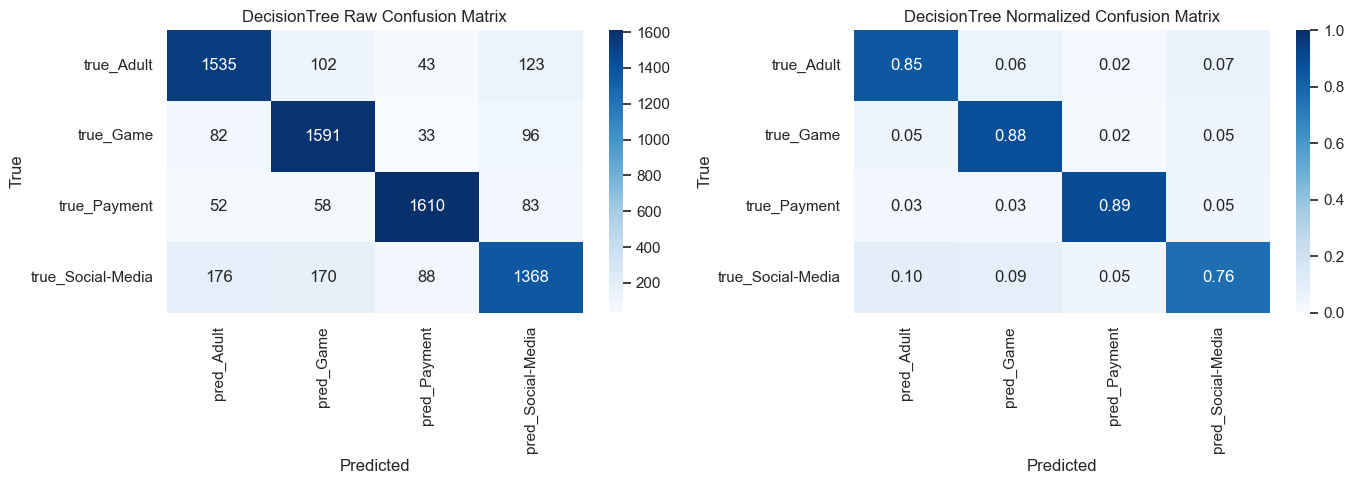

Best single model: DecisionTree
Confusion matrix figure: outputs\final_work\DecisionTree_confusion_matrix.png


,pred_Adult,pred_Game,pred_Payment,pred_Social-Media
true_Adult,1535,102,43,123
true_Game,82,1591,33,96
true_Payment,52,58,1610,83
true_Social-Media,176,170,88,1368


,pred_Adult,pred_Game,pred_Payment,pred_Social-Media
true_Adult,0.8514,0.0566,0.0238,0.0682
true_Game,0.0455,0.8829,0.0183,0.0533
true_Payment,0.0288,0.0322,0.8930,0.0460
true_Social-Media,0.0977,0.0943,0.0488,0.7592


,precision,recall,f1-score,support
Adult,0.8320,0.8514,0.8416,1803.0000
Game,0.8282,0.8829,0.8547,1802.0000
Payment,0.9076,0.8930,0.9002,1803.0000
Social-Media,0.8192,0.7592,0.7880,1802.0000
accuracy,0.8466,0.8466,0.8466,0.8466
macro avg,0.8467,0.8466,0.8461,7210.0000
weighted avg,0.8467,0.8466,0.8461,7210.0000


,model_name,class_label,tp,tn,fp,fn,specificity,false_positive_rate,false_negative_rate,negative_predictive_value
0,DecisionTree,Adult,1535,5097,310,268,0.9427,0.0573,0.1486,0.9500
1,DecisionTree,Game,1591,5078,330,211,0.9390,0.0610,0.1171,0.9601
2,DecisionTree,Payment,1610,5243,164,193,0.9697,0.0303,0.1070,0.9645
3,DecisionTree,Social-Media,1368,5106,302,434,0.9442,0.0558,0.2408,0.9217


In [50]:
best_single_predictions = single_model_predictions[best_single_model_name]

best_single_confusion_raw, best_single_confusion_normalized, best_single_confusion_figure = plot_confusion_outputs(
    best_single_model_name,
    y_test,
    best_single_predictions,
    class_labels,
    best_single_model_name,
)

best_single_report = pd.DataFrame(
    classification_report(
        y_test,
        best_single_predictions,
        output_dict=True,
        zero_division=0,
    )
).T.round(4)

best_single_one_vs_rest = build_one_vs_rest_table(
    best_single_model_name,
    y_test,
    best_single_predictions,
    class_labels,
)

best_single_report_path = final_work_output_dir / f"{best_single_model_name}_classification_report.csv"
best_single_report.to_csv(best_single_report_path)

print(f"Best single model: {best_single_model_name}")
print(f"Confusion matrix figure: {best_single_confusion_figure}")
display(best_single_confusion_raw)
display(best_single_confusion_normalized)
display(best_single_report)
display(best_single_one_vs_rest)


## Step 51: Best Hybrid Model Confusion Matrix


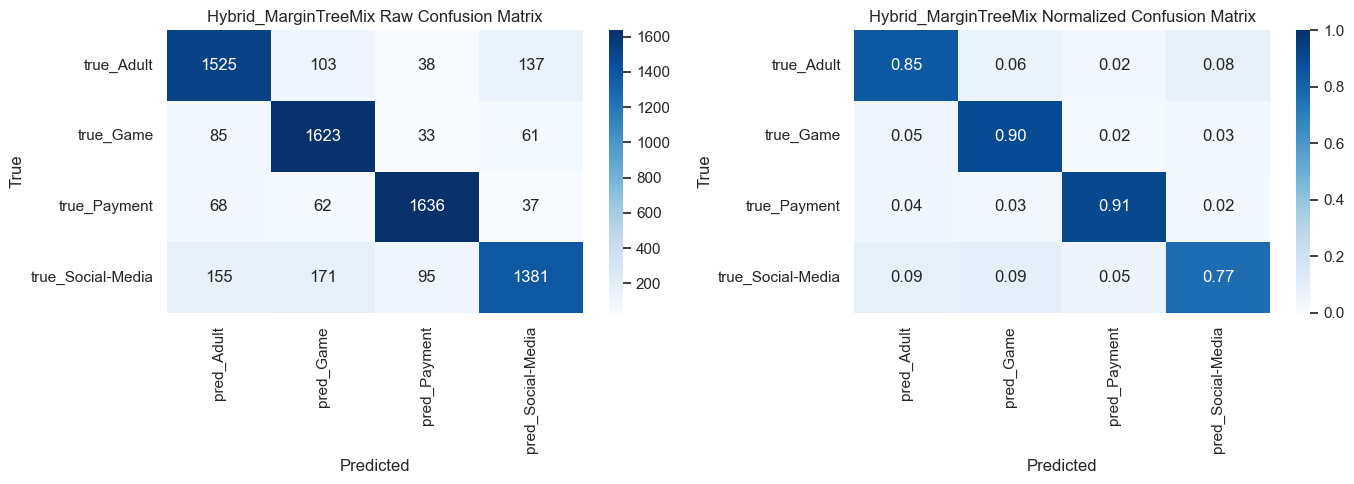

Best hybrid model: Hybrid_MarginTreeMix
Confusion matrix figure: outputs\final_work\Hybrid_MarginTreeMix_confusion_matrix.png


,pred_Adult,pred_Game,pred_Payment,pred_Social-Media
true_Adult,1525,103,38,137
true_Game,85,1623,33,61
true_Payment,68,62,1636,37
true_Social-Media,155,171,95,1381


,pred_Adult,pred_Game,pred_Payment,pred_Social-Media
true_Adult,0.8458,0.0571,0.0211,0.0760
true_Game,0.0472,0.9007,0.0183,0.0339
true_Payment,0.0377,0.0344,0.9074,0.0205
true_Social-Media,0.0860,0.0949,0.0527,0.7664


,precision,recall,f1-score,support
Adult,0.8320,0.8458,0.8388,1803.0000
Game,0.8285,0.9007,0.8631,1802.0000
Payment,0.9079,0.9074,0.9076,1803.0000
Social-Media,0.8546,0.7664,0.8081,1802.0000
accuracy,0.8551,0.8551,0.8551,0.8551
macro avg,0.8557,0.8551,0.8544,7210.0000
weighted avg,0.8557,0.8551,0.8544,7210.0000


,model_name,class_label,tp,tn,fp,fn,specificity,false_positive_rate,false_negative_rate,negative_predictive_value
0,Hybrid_MarginTreeMix,Adult,1525,5099,308,278,0.9430,0.0570,0.1542,0.9483
1,Hybrid_MarginTreeMix,Game,1623,5072,336,179,0.9379,0.0621,0.0993,0.9659
2,Hybrid_MarginTreeMix,Payment,1636,5241,166,167,0.9693,0.0307,0.0926,0.9691
3,Hybrid_MarginTreeMix,Social-Media,1381,5173,235,421,0.9565,0.0435,0.2336,0.9247


In [51]:
best_hybrid_predictions = hybrid_model_predictions[best_hybrid_name]

best_hybrid_confusion_raw, best_hybrid_confusion_normalized, best_hybrid_confusion_figure = plot_confusion_outputs(
    best_hybrid_name,
    y_test,
    best_hybrid_predictions,
    class_labels,
    best_hybrid_name,
)

best_hybrid_report = pd.DataFrame(
    classification_report(
        y_test,
        best_hybrid_predictions,
        output_dict=True,
        zero_division=0,
    )
).T.round(4)

best_hybrid_one_vs_rest = build_one_vs_rest_table(
    best_hybrid_name,
    y_test,
    best_hybrid_predictions,
    class_labels,
)

best_hybrid_report_path = final_work_output_dir / f"{best_hybrid_name}_classification_report.csv"
best_hybrid_report.to_csv(best_hybrid_report_path)

print(f"Best hybrid model: {best_hybrid_name}")
print(f"Confusion matrix figure: {best_hybrid_confusion_figure}")
display(best_hybrid_confusion_raw)
display(best_hybrid_confusion_normalized)
display(best_hybrid_report)
display(best_hybrid_one_vs_rest)


## Step 52: Final Selection Summary


In [52]:
final_selection_summary = pd.DataFrame(
    [
        {
            "selection_type": "best_single_model",
            "model_name": best_single_model_name,
            "macro_f1": best_single_model_row["macro_f1"],
            "accuracy": best_single_model_row["accuracy"],
        },
        {
            "selection_type": "best_hybrid_model",
            "model_name": best_hybrid_name,
            "macro_f1": best_hybrid_row["macro_f1"],
            "accuracy": best_hybrid_row["accuracy"],
        },
    ]
)

display(final_selection_summary)


,selection_type,model_name,macro_f1,accuracy
0,best_single_model,DecisionTree,0.8461,0.8466
1,best_hybrid_model,Hybrid_MarginTreeMix,0.8544,0.8551


## Step 53: C Export Setup


In [54]:
import importlib
import subprocess
import sys

if importlib.util.find_spec("m2cgen") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "m2cgen"])

import re

import m2cgen as m2c

c_output_dir = Path("outputs") / "final_work_c"
c_output_dir.mkdir(parents=True, exist_ok=True)


def make_c_identifier(text):
    cleaned = re.sub(r"[^0-9a-zA-Z_]", "_", str(text))
    cleaned = re.sub(r"_+", "_", cleaned).strip("_")
    if not cleaned:
        cleaned = "model"
    if cleaned[0].isdigit():
        cleaned = f"model_{cleaned}"
    return cleaned.lower()


def cleaned_m2c_code(model, function_name):
    raw_code = m2c.export_to_c(model)
    lines = [line for line in raw_code.splitlines() if not line.startswith("#include")]
    code = "\n".join(lines)
    return code.replace(
        "void score(double * input, double * output)",
        f"static void {function_name}(double * input, double * output)",
        1,
    )


def build_class_label_block(class_labels):
    return ", ".join(f'"{label}"' for label in class_labels)


def feature_map_from_pipeline(fitted_pipeline, model_name, input_space):
    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    return pd.DataFrame(
        {
            "model_name": model_name,
            "input_space": input_space,
            "transformed_index": range(len(preprocessor.get_feature_names_out())),
            "transformed_feature": preprocessor.get_feature_names_out(),
        }
    )


def pipeline_input_space(model_name):
    if model_name in {"LogisticRegression", "SGDLogLoss", "LinearSVC"}:
        return "linear_transformed_vector"
    return "tree_transformed_vector"


def export_single_model_to_c(model_name, fitted_pipeline):
    fitted_model = fitted_pipeline.named_steps["model"]
    model_id = make_c_identifier(model_name)
    source_path = c_output_dir / f"{model_name}_best_single.c"
    feature_map_path = c_output_dir / f"{model_name}_best_single_feature_map.csv"

    c_source = f'''
#include <stddef.h>
#include <string.h>

#define NUM_CLASSES {len(fitted_model.classes_)}
static const char *CLASS_LABELS[NUM_CLASSES] = {{{build_class_label_block(list(fitted_model.classes_))}}};

static int argmax_index(const double *values, int length) {{
    int best_index = 0;
    for (int i = 1; i < length; ++i) {{
        if (values[i] > values[best_index]) {{
            best_index = i;
        }}
    }}
    return best_index;
}}

{cleaned_m2c_code(fitted_model, f"{model_id}_score")}

int {model_id}_predict(const double *input, double *output) {{
    {model_id}_score((double *)input, output);
    return argmax_index(output, NUM_CLASSES);
}}

const char* {model_id}_label(int index) {{
    return CLASS_LABELS[index];
}}
'''.strip()

    source_path.write_text(c_source, encoding="utf-8")
    feature_map_from_pipeline(
        fitted_pipeline,
        model_name,
        pipeline_input_space(model_name),
    ).to_csv(feature_map_path, index=False)

    return pd.DataFrame(
        [
            {
                "artifact": "best_single_c_source",
                "model_name": model_name,
                "path": str(source_path),
                "input_space": pipeline_input_space(model_name),
            },
            {
                "artifact": "best_single_feature_map",
                "model_name": model_name,
                "path": str(feature_map_path),
                "input_space": pipeline_input_space(model_name),
            },
        ]
    )


def export_hybrid_model_to_c(hybrid_name):
    current_estimators = hybrid_model_specs[hybrid_name]
    class_labels = list(current_estimators[0][1].named_steps["model"].classes_)
    hybrid_id = make_c_identifier(hybrid_name)

    source_parts = [
        f'''
#include <stddef.h>
#include <string.h>

#define NUM_CLASSES {len(class_labels)}
static const char *CLASS_LABELS[NUM_CLASSES] = {{{build_class_label_block(class_labels)}}};

static int argmax_index(const double *values, int length) {{
    int best_index = 0;
    for (int i = 1; i < length; ++i) {{
        if (values[i] > values[best_index]) {{
            best_index = i;
        }}
    }}
    return best_index;
}}
'''.strip()
    ]

    manifest_rows = []
    feature_map_rows = []

    for alias_name, fitted_pipeline in current_estimators:
        base_model_name = estimator_alias_to_single_name[alias_name]
        fitted_model = fitted_pipeline.named_steps["model"]
        member_id = make_c_identifier(f"{hybrid_name}_{alias_name}")
        input_space = pipeline_input_space(base_model_name)
        feature_map_rows.append(
            feature_map_from_pipeline(
                fitted_pipeline,
                base_model_name,
                input_space,
            ).assign(member_alias=alias_name)
        )
        manifest_rows.append(
            {
                "hybrid_name": hybrid_name,
                "member_alias": alias_name,
                "base_model_name": base_model_name,
                "input_space": input_space,
            }
        )

        source_parts.append(cleaned_m2c_code(fitted_model, f"{member_id}_score"))
        source_parts.append(
            f'''
static int {member_id}_predict(const double *input, double *output) {{
    {member_id}_score((double *)input, output);
    return argmax_index(output, NUM_CLASSES);
}}
'''.strip()
        )

    vote_lines = [
        f"int {hybrid_id}_predict(const double *linear_input, const double *tree_input, double *votes) {{",
        "    for (int i = 0; i < NUM_CLASSES; ++i) {",
        "        votes[i] = 0.0;",
        "    }",
    ]

    for alias_name, _ in current_estimators:
        base_model_name = estimator_alias_to_single_name[alias_name]
        member_id = make_c_identifier(f"{hybrid_name}_{alias_name}")
        source_name = "linear_input" if pipeline_input_space(base_model_name) == "linear_transformed_vector" else "tree_input"
        vote_lines.extend(
            [
                "    {",
                "        double member_output[NUM_CLASSES];",
                f"        int predicted_index = {member_id}_predict({source_name}, member_output);",
                "        votes[predicted_index] += 1.0;",
                "    }",
            ]
        )

    vote_lines.extend(
        [
            "    return argmax_index(votes, NUM_CLASSES);",
            "}",
            "",
            f"const char* {hybrid_id}_label(int index) {{",
            "    return CLASS_LABELS[index];",
            "}",
        ]
    )

    source_parts.append("\n".join(vote_lines))

    source_path = c_output_dir / f"{hybrid_name}_best_hybrid.c"
    manifest_path = c_output_dir / f"{hybrid_name}_best_hybrid_manifest.csv"
    feature_map_path = c_output_dir / f"{hybrid_name}_best_hybrid_feature_map.csv"

    source_path.write_text("\n\n".join(source_parts), encoding="utf-8")
    pd.DataFrame(manifest_rows).to_csv(manifest_path, index=False)
    pd.concat(feature_map_rows, ignore_index=True).to_csv(feature_map_path, index=False)

    return pd.DataFrame(
        [
            {
                "artifact": "best_hybrid_c_source",
                "model_name": hybrid_name,
                "path": str(source_path),
                "input_space": "linear_input + tree_input",
            },
            {
                "artifact": "best_hybrid_manifest",
                "model_name": hybrid_name,
                "path": str(manifest_path),
                "input_space": "linear_input + tree_input",
            },
            {
                "artifact": "best_hybrid_feature_map",
                "model_name": hybrid_name,
                "path": str(feature_map_path),
                "input_space": "linear_input + tree_input",
            },
        ]
    )


## Step 54: Export Best Single Model To C


In [55]:
best_single_c_summary = export_single_model_to_c(
    best_single_model_name,
    best_single_estimators[best_single_model_name],
)

print(f"Best single model for C export: {best_single_model_name}")
display(best_single_c_summary)


Best single model for C export: DecisionTree


,artifact,model_name,path,input_space
0,best_single_c_source,DecisionTree,outputs\final_work_c\DecisionTree_best_single.c,tree_transformed_vector
1,best_single_feature_map,DecisionTree,outputs\final_work_c\DecisionTree_best_single_feature_map.csv,tree_transformed_vector


## Step 55: Export Best Hybrid Model To C


In [56]:
best_hybrid_c_summary = export_hybrid_model_to_c(best_hybrid_name)

print(f"Best hybrid model for C export: {best_hybrid_name}")
display(best_hybrid_c_summary)


Best hybrid model for C export: Hybrid_MarginTreeMix


,artifact,model_name,path,input_space
0,best_hybrid_c_source,Hybrid_MarginTreeMix,outputs\final_work_c\Hybrid_MarginTreeMix_best_hybrid.c,linear_input + tree_input
1,best_hybrid_manifest,Hybrid_MarginTreeMix,outputs\final_work_c\Hybrid_MarginTreeMix_best_hybrid_manifest.csv,linear_input + tree_input
2,best_hybrid_feature_map,Hybrid_MarginTreeMix,outputs\final_work_c\Hybrid_MarginTreeMix_best_hybrid_feature_map.csv,linear_input + tree_input


## Step 56: Final C Artifacts


In [57]:
final_c_artifacts = pd.concat(
    [best_single_c_summary, best_hybrid_c_summary],
    ignore_index=True,
)

display(final_c_artifacts)


,artifact,model_name,path,input_space
0,best_single_c_source,DecisionTree,outputs\final_work_c\DecisionTree_best_single.c,tree_transformed_vector
1,best_single_feature_map,DecisionTree,outputs\final_work_c\DecisionTree_best_single_feature_map.csv,tree_transformed_vector
2,best_hybrid_c_source,Hybrid_MarginTreeMix,outputs\final_work_c\Hybrid_MarginTreeMix_best_hybrid.c,linear_input + tree_input
3,best_hybrid_manifest,Hybrid_MarginTreeMix,outputs\final_work_c\Hybrid_MarginTreeMix_best_hybrid_manifest.csv,linear_input + tree_input
4,best_hybrid_feature_map,Hybrid_MarginTreeMix,outputs\final_work_c\Hybrid_MarginTreeMix_best_hybrid_feature_map.csv,linear_input + tree_input
